In [75]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

In [ ]:
# ! wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

--2026-09-21 08:12:40--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.01s   

2026-09-21 08:12:40 (60.7 MB/s) - ‘car_fuel_efficiency_2026.csv’ saved [635180/635180]



In [3]:
#loading the required dataset 
carfuel_df = pd.read_csv("car_fuel_efficiency_2026.csv")
carfuel_df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [ ]:
# feature selection for downstream processes 
carfuel_df = carfuel_df[['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']]

carfuel_df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


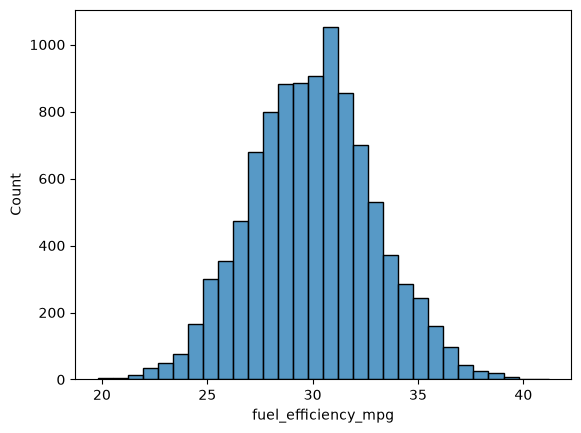

In [10]:
#doing exploratory data analysis (EDA)
sns.histplot(carfuel_df["fuel_efficiency_mpg"],bins = 30);#checking the target value has long tail or not

In [11]:
#checking the feature selected dataset for missing values
carfuel_df.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [12]:
#finding the 50% percentile of horsepower
carfuel_df.horsepower.median()

np.float64(254.0)

In [57]:
#preparing the dataset for train, validation, and test
n = len(carfuel_df)
n_train = int(0.6 * n)
n_val = int(0.2*(n))
n_test = int(0.2* (n))
# n_train = n - (n_val+n_test)

print(n == (n_train+n_val+n_test))


True


In [58]:
idx = np.arange(n)
np.random.shuffle(idx)
np.random.seed(42)

train_set = carfuel_df.iloc[idx[:n_train]]
val_set = carfuel_df.iloc[idx[n_train:(n_val+n_train)]]
test_set = carfuel_df.iloc[idx[n_val+n_train:]]

In [65]:
#reset messy indexes 
train_set = train_set.reset_index(drop=True)
val_set = val_set.reset_index(drop=True)
test_set = test_set.reset_index(drop=True)

In [71]:
#building LinearRegresion model without Regularization
linearreg = LinearRegression()

In [72]:
#handling missing vlaues and training Regression model and comparing RMSE
# first method--> filling with 0 

train_cop = train_set.copy()
val_cop = val_set.copy()
test_cop = test_set.copy()

train_cop = train_cop.fillna(0)
val_cop  = val_cop.fillna(0)
test_cop = test_cop.fillna(0)


In [74]:
X_train = train_cop.drop(columns='fuel_efficiency_mpg')
y_train = train_cop[['fuel_efficiency_mpg']]

X_val = val_cop.drop(columns='fuel_efficiency_mpg')
y_val = val_cop[['fuel_efficiency_mpg']]

X_test = test_cop.drop(columns='fuel_efficiency_mpg')
y_test = test_cop[['fuel_efficiency_mpg']]

In [80]:
#training the model 
linearreg.fit(X_train,y_train)
predictions_1 = linearreg.predict(X_val)
rmse_1 = root_mean_squared_error(predictions_1,y_val)
print(round(rmse_1,3))

2.205


In [82]:
# first method--> filling with mean (calculate using only training set)
mean = train_set["horsepower"].mean()

train_set.horsepower = train_set.horsepower.fillna(mean)
val_set.horsepower = val_set.horsepower.fillna(mean)
test_set.horsepower = test_set.horsepower.fillna(mean)

In [84]:
X_train_mean = train_set.drop(columns='fuel_efficiency_mpg')
y_train_mean = train_set[['fuel_efficiency_mpg']]

X_val_mean = val_set.drop(columns='fuel_efficiency_mpg')
y_val_mean = val_set[['fuel_efficiency_mpg']]

X_test_mean = test_set.drop(columns='fuel_efficiency_mpg')
y_test_mean = test_set[['fuel_efficiency_mpg']]

In [85]:
#training linearregression 
linearreg_mean = LinearRegression()

linearreg_mean.fit(X_train_mean,y_train_mean)
mean_pred =  linearreg_mean.predict(X_val_mean)
rmse_2 = root_mean_squared_error(mean_pred,y_val_mean)
print(round(rmse_2,3))

2.202
